# Bài thực hành 1

## Vấn đề 
_Dự đoán khả năng tiến triển của bệnh tiểu đường thông qua các chỉ số sinh lý của cơ thể._


## Thông tin dữ liệu:

- Số lượng mẫu: 442 (thông tin từ 442 bệnh nhân)
- Số lượng thuộc tính:
    Thông tin các thuộc tính (10 cột giá trị đầu tiên): Age(tuổi), Sex (giới tính), 
    Body mass index (chỉ số khối cơ thể), Average blood pressure(huyết ap trung bình), S1, S2, S3, S4, S5, S6 (sáu phép đo huyết thanh khác).
- Mục tiêu:	Cột 11, chỉ số đánh giá mức độ tiến triển của bệnh 1 năm sau khi điều trị. 

**! Chú ý: Dữ liệu thông tin thuộc tính đã được chuẩn hoá**

Xem thêm thông tin về nguồn dữ liệu tại: (https://www4.stat.ncsu.edu/~boos/var.select/diabetes.html)


# Hướng giải quyết

Giả sử rằng khả năng tiến triển của bệnh tiểu đường (ký hiệu: `y`) là đại lượng phụ thuộc tuyến tính vào các thông tin sinh lý của bệnh nhân như các thuộc tính đã mô tả ở trên (tuổi, giới tính, chỉ số khối, ... - ký hiệu: `x1, x2, .. x_n`) : 

`y = w0 + w1*x1 + w2*x2 + ... + w_n*x_n`

Mục tiêu: Tìm được bộ trọng số `[w0, w1, ... w_n]` biểu diễn mối quan hệ này. 

# Thư viện sử dụng 

- matplotlib: phục vụ vẽ các đồ thị 
- numpy: tính toán các phép biến đổi trên ma trận / vector 
- math: thực hiện một số hàm tính toán 
- pandas: phục vụ chuyển đổi trên dữ liệu dạng bảng 
- scikit-learn: (sklearn) thư viện hỗ trợ xây dựng các mô hình học máy, các hàm training và testing. 


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd 
import math 

from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score


# Đọc dữ liệu 

Dữ liệu về bệnh tiểu đường được hỗ trợ bởi sklearn, đọc dữ liệu thông qua hàm `datasets.load_diabetes()` 

Xem thêm các bộ dữ liệu khác tại https://scikit-learn.org/stable/datasets/index.html#toy-datasets.
https://scikit-learn.org/stable/datasets/toy_dataset.html

Dữ liệu nhận về ở dạng object với các thành phần thuộc tính:

- data: ma trận 2 chiều (442x10) - các thông tin bệnh nhân được chuẩn hoá về dạng số thực. 
- target: mảng các số thực (442,) - chỉ số tiến triển của bệnh tiểu đường. 

In [2]:
# lay du lieu diabetes - du lieu ve benh tieu duong
diabetes = datasets.load_diabetes()
print("Số chiều dữ liệu input: ", diabetes.data.shape)
print("Kiểu dữ liệu input: ", type(diabetes.data))
print("Số chiều dữ liệu target: ", diabetes.target.shape)
print("Kiểu dữ liệu target: ", type(diabetes.target))
print()

print("5 mẫu dữ liệu đầu tiên:")
print("input: ", diabetes.data[:5])
print("target: ",diabetes.target[:5])
#print("data[5,1]", diabetes.data[4,1])

Số chiều dữ liệu input:  (442, 10)
Kiểu dữ liệu input:  <class 'numpy.ndarray'>
Số chiều dữ liệu target:  (442,)
Kiểu dữ liệu target:  <class 'numpy.ndarray'>

5 mẫu dữ liệu đầu tiên:
input:  [[ 0.03807591  0.05068012  0.06169621  0.02187239 -0.0442235  -0.03482076
  -0.04340085 -0.00259226  0.01990749 -0.01764613]
 [-0.00188202 -0.04464164 -0.05147406 -0.02632753 -0.00844872 -0.01916334
   0.07441156 -0.03949338 -0.06833155 -0.09220405]
 [ 0.08529891  0.05068012  0.04445121 -0.00567042 -0.04559945 -0.03419447
  -0.03235593 -0.00259226  0.00286131 -0.02593034]
 [-0.08906294 -0.04464164 -0.01159501 -0.03665608  0.01219057  0.02499059
  -0.03603757  0.03430886  0.02268774 -0.00936191]
 [ 0.00538306 -0.04464164 -0.03638469  0.02187239  0.00393485  0.01559614
   0.00814208 -0.00259226 -0.03198764 -0.04664087]]
target:  [151.  75. 141. 206. 135.]


**Chia dữ liệu làm 2 phần training 362 mẫu và testing 80 mẫu** 

In [3]:
# cat nho du lieu, lay 1 phan cho qua trinh thu nghiem,
# chia train test cac mau du lieu
# diabetes_X = diabetes.data[:, np.newaxis, 2]
diabetes_X = diabetes.data

diabetes_X_train = diabetes_X[:361]
diabetes_y_train = diabetes.target[:361]

diabetes_X_test = diabetes_X[362:]
diabetes_y_test = diabetes.target[362:]

# Xây dựng mô hình Regression sử dụng Sklearn

Thử nghiệm xây dựng mô hình hồi quy (Linear Regression / Ridge Regression) để học được bộ tham số

- [Linear Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) `linear_model.LinearRegression()`
- [Ridge Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html#sklearn.linear_model.Ridge) `linear_model.Ridge()`

In [4]:
# Xay dung model su dung sklearn
regr = linear_model.LinearRegression()


In [5]:
##### exercise #####
# Yêu cầu: Cài đặt mô hình Ridge Regression với alpha = 0.1
# Gợi ý: xem hướng dẫn tại https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html
######################
regr_ridge=linear_model.Ridge(0.1)

# Training mô hình

Sử dụng Dữ liệu đã được chia ở bước trước đó để thực hiện training model. 

=> Tìm được bộ trọng số `[w0, w1, ... w_n]`

In [6]:
# Huấn luyện mô hình Linear Regression
regr.fit(diabetes_X_train, diabetes_y_train)
print("[w1, ... w_n] = ", regr.coef_)
print("w0 = ", regr.intercept_)

[w1, ... w_n] =  [-1.12982324e-02 -2.49782541e+02  5.18802202e+02  2.97220454e+02
 -6.39802236e+02  3.56330510e+02  2.77834385e+01  1.46962789e+02
  6.90474996e+02  1.05716702e+02]
w0 =  152.56041961097782


In [7]:
##### exercise #####
# Yêu cầu: Huấn luyện mô hình Ridge Regression và in ra các trọng số w0, w1, ...,wn của mô hình
# Gợi ý: xem hướng dẫn tại https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html
######################
regr_ridge.fit(diabetes_X_train, diabetes_y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [8]:
##### exercise #####
# Yêu cầu: tính giá trị dự đoán của mô hình trên mẫu đầu tiên của tập test và so sánh với kết quả của thư viện
# Gợi ý: sử dụng công thức y = w0 + w1*x1 + w1*x2 + ... + w_n*x_n
######################
#Dự đoán thử cho trường hợp đầu tiên

#Giá trị đúng
print("Gia tri true: ", diabetes_y_test[0])

#Dự đoán cho mô hình Linear Regression sử dụng hàm dự đoán của thư viện
y_pred_linear = regr.predict(diabetes_X_test[0:1])     
print("Gia tri du doan cho mô hình linear regression: ", y_pred_linear)

#Viết code tính và in kết quả dự đoán cho mô hình Linear Regression sử dụng công thức tại đây
b0=regr.intercept_
w0=regr.coef_
y_calc_linear=b0+np.dot(diabetes_X_test[0:1], w0)
print("Gia tri tinh dung cong thuc cho mo hinh linear regression: ", y_calc_linear)

#Dự đoán cho mô hình Ridge Regression sử dụng hàm dự đoán của thư viện
y_pred_ridge = regr_ridge.predict(diabetes_X_test[0:1])  
print("Gia tri du doan cho mô hình ridge regression: ", y_pred_ridge)

#Viết code tính và in kết quả dự đoán cho mô hình Ridge Regression sử dụng công thức tại đây
b1=regr_ridge.intercept_
w1=regr_ridge.coef_
y_calc_ridge=b1+np.dot(diabetes_X_test[0:1], w1)
print("Gia tri tinh dung cong thuc cho mo hinh ridge regression: ", y_calc_ridge)
######################

Gia tri true:  321.0
Gia tri du doan cho mô hình linear regression:  [234.35947872]
Gia tri tinh dung cong thuc cho mo hinh linear regression:  [234.35947872]
Gia tri du doan cho mô hình ridge regression:  [226.73474004]
Gia tri tinh dung cong thuc cho mo hinh ridge regression:  [226.73474004]


# Dự đoán các mẫu dữ liệu trong tập test 

In [9]:
# Thực hiện suy diễn sau khi huấn luyện
diabetes_y_pred = regr.predict(diabetes_X_test)
pd.DataFrame(data=np.array([diabetes_y_test, diabetes_y_pred,
                            abs(diabetes_y_test - diabetes_y_pred)]).T,
             columns=["Thực tế", "Dự đoán", "Lệch"])  

# pd.DataFrame(data=np.array([diabetes_y_test, diabetes_y_pred,
#                             abs(diabetes_y_test - diabetes_y_pred)]), 
#              index=["Thực tế", "Dự đoán", "Lệch"])  

,Thực tế,Dự đoán,Lệch
0,321.0,234.359479,86.640521
1,58.0,163.999748,105.999748
2,262.0,163.520115,98.479885
3,206.0,167.189446,38.810554
4,233.0,254.806697,21.806697
...,...,...,...
75,178.0,191.710701,13.710701
76,104.0,104.626354,0.626354
77,132.0,122.693494,9.306506
78,220.0,210.454911,9.545089


# Đánh giá 

Sử dụng độ đo RMSE tính căn bậc 2 của trung bình bình phương lỗi. 
> $\text{RMSE}(y, \hat{y}) = \sqrt{\frac{1}{n_\text{samples}} \sum_{i=0}^{n_\text{samples} - 1} (y_i - \hat{y}_i)^2}.$

- Lỗi càng nhỏ càng thể hiện mô hình có khả năng học và dự đoán hiệu quả 
- Như thế nào là nhỏ ? 

In [10]:
# Giá trị RMSE của mô hình Linear Regression
math.sqrt(mean_squared_error(diabetes_y_test, diabetes_y_pred))

51.53921127468042

In [16]:
##### exercise #####
# Yêu cầu: đánh giá độ đo RMSE của mô hình Ridge Regression với các hằng số phạt khác nhau, in ra kết quả.
# Gợi ý: Các bước làm:
# - Lặp theo danh sách các hằng số phạt
# - Dựng các mô hình Ridge Regression với mỗi hằng số phạt tương ứng
# - Huấn luyện các mô hình và dự đoán 
# - Tính RMSE tương ứng
######################

#Các giá trị hằng số phạt cho trước
_lambda = [0, 0.0001,0.01, 0.04, 0.05, 0.06, 0.1, 0.5, 1, 5, 10, 20]
for x in _lambda:
    regr_ridge_l1=linear_model.Ridge(x)
    regr_ridge_l1.fit(diabetes_X_train, diabetes_y_train)
    diabetes_y_pred1=regr_ridge_l1.predict(diabetes_X_test)
    rmse=math.sqrt(mean_squared_error(diabetes_y_test, diabetes_y_pred1))
    print(x, ' ', rmse)

0   51.5392112746804
0.0001   51.54635240923979
0.01   51.88866069785608
0.04   52.11211596712347
0.05   52.1525463622131
0.06   52.190775700363055
0.1   52.34759792652382
0.5   54.613321511474574
1   57.382574887617025
5   67.24133680169886
10   71.18738262709283
20   74.05735936735674


## Vẽ biểu đồ phân phối cho chỉ số thực tế

,values
count,80.00000
mean,152.38750
std,78.46994
min,40.00000
25%,72.00000
50%,140.00000
75%,217.50000
max,321.00000


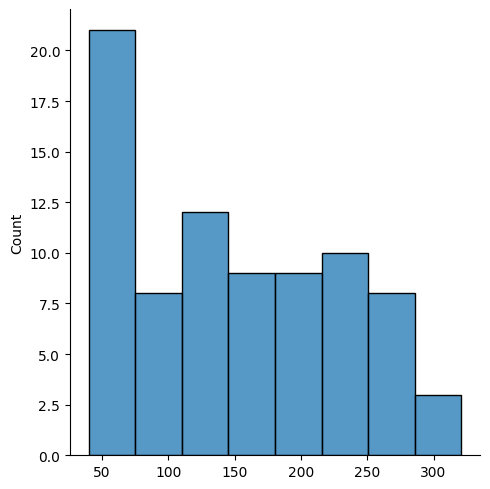

In [17]:
import seaborn as sns
sns.displot(diabetes_y_test)
pd.DataFrame(data=diabetes_y_test, columns=["values"]).describe()

## Vẽ biểu đồ phân phối cho chỉ số dự đoán của mô hình linear regression

,values
count,80.000000
mean,155.501049
std,57.511599
min,49.193721
25%,112.399159
50%,161.143223
75%,191.047878
max,279.598577


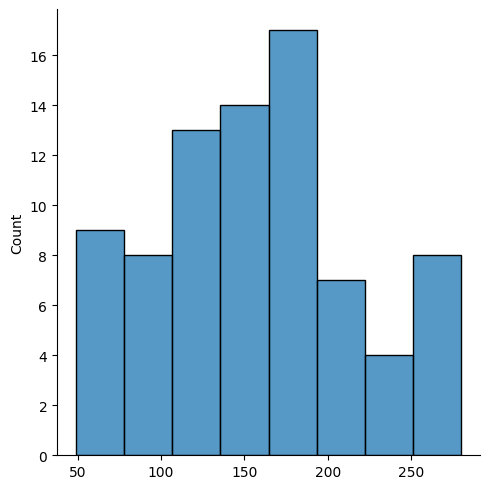

In [20]:
##### exercise #####
# Yêu cầu: Tính các chỉ số thống kê và vẽ biểu đồ phân phối của chỉ số dự đoán bằng mô hình Linear Regression, quan sát và nhận xét
# Gợi ý: sử dụng sns và pd
######################
sns.displot(diabetes_y_pred)
pd.DataFrame(data=diabetes_y_pred, columns=["values"]).describe()

## Vẽ biểu đồ so sánh kết quả dự đoán và thực tế

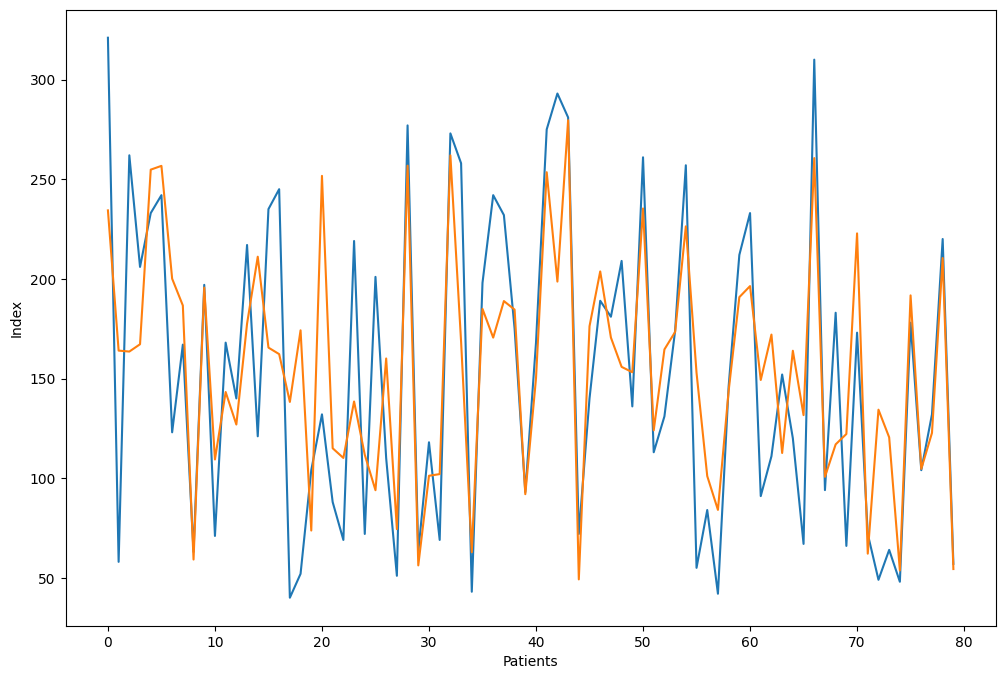

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
 
plt.plot(diabetes_y_test)
plt.plot(diabetes_y_pred)
 
plt.xlabel('Patients')

plt.ylabel('Index')
 
 
# function to show the plot
plt.show()